# <a id='toc1_'></a>[Lecture 4: IS-LM, monetary policy, and aggregate demand](#toc0_)

**Macroeconomics B -- Chapter 17**

By the end of this notebook you will be able to:
1. Compute the IS curve from an exact linear goods-market benchmark.
2. Solve and plot a full IS-LM model with an upward-sloping LM curve.
3. Compare the traditional LM curve with a horizontal monetary-policy line.
4. Trace how the Taylor rule maps inflation into aggregate demand.
5. Connect policy-rate and balance-sheet data to the model.

**Table of contents**<a id='toc0_'></a>
- [Lecture 4: IS-LM, monetary policy, and aggregate demand](#toc1_)
  - [Notebook map and calibration](#toc1_1_)
  - [Exact linear IS benchmark and multiplier](#toc1_2_)
    - [Try it yourself](#toc1_2_1_)
  - [The full IS-LM model](#toc1_3_)
    - [Try it yourself](#toc1_3_1_)
  - [The Taylor rule and the horizontal policy line](#toc1_4_)
    - [Try it yourself](#toc1_4_1_)
  - [From IS-LM to the AD curve](#toc1_5_)
    - [Bridge figure: tracing AD from IS and the policy line](#toc1_5_1_)
    - [Try it yourself](#toc1_5_2_)
  - [Data lab: policy rates and central bank balance sheets](#toc1_6_)
    - [FRED data access](#toc1_6_1_)
  - [Summary](#toc1_7_)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Global plot settings
plt.rcParams.update({'axes.grid': True, 'grid.color': 'black',
                     'grid.alpha': 0.25, 'grid.linestyle': '--'})
plt.rcParams.update({'font.size': 14})

# Reproducibility
rng = np.random.default_rng(2026)

## <a id='toc1_1_'></a>[Notebook map and calibration](#toc0_)

| Notebook section | Main idea |
|---|---|
| 1. Exact linear IS benchmark and multiplier | Compute the reduced-form IS coefficients from primitive spending parameters. |
| 2. The full IS-LM model | Solve for output and the real rate when IS meets an upward-sloping LM curve. |
| 3. The Taylor rule and the horizontal policy line | Replace LM with the central bank's chosen real rate. |
| 4. From IS-LM to the AD curve | Use the policy rule to map inflation into aggregate demand. |
| 5. Data lab | Connect policy rates and central-bank balance sheets to the model mechanisms. |

The parameter values are teaching calibrations. They are chosen to make the mechanisms visible in a graph, not to estimate Denmark or the euro area.

## <a id='toc1_2_'></a>[Exact linear IS benchmark and multiplier](#toc0_)

The exact linear benchmark starts from primitive spending parameters and turns them into reduced-form IS coefficients. The multiplier determines how strongly spending shocks move output, while the interest coefficient governs the slope of the IS curve.

Multiplier alpha1 = 1.72
Interest coefficient alpha2 = 1.38
Tax coefficient alpha3 = 1.03


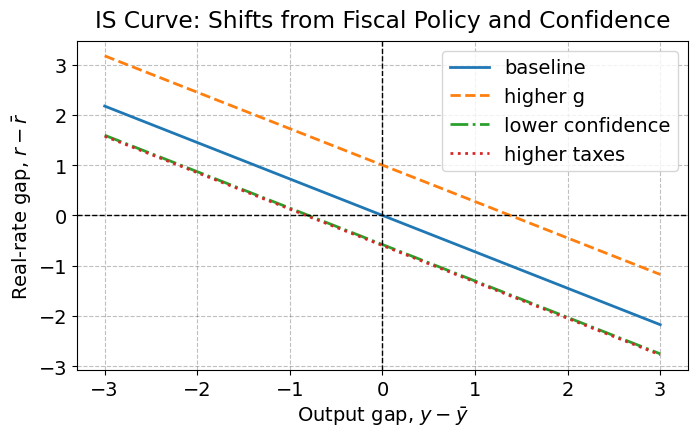

In [2]:
# === Primitive parameters for the exact linear benchmark ===
par_linear = {
    'c': 0.60,      # marginal propensity to consume
    't': 0.30,      # marginal tax rate
    'b': 0.80,      # interest sensitivity of investment
    'g_gap': 0.0,   # government-demand shock
    'tau_gap': 0.0, # tax shock
    'v': 0.0,       # autonomous private-demand shock
}

def reduced_form_is_parameters(p):
    '''Return the reduced-form IS coefficients from the exact benchmark.'''
    c = p['c']
    t = p['t']
    b = p['b']

    multiplier = 1.0 / (1.0 - c * (1.0 - t))
    out = {
        'alpha1': multiplier,
        'alpha2': b * multiplier,
        'alpha3': c * multiplier,
        'g_gap': p['g_gap'],
        'tau_gap': p['tau_gap'],
        'v': p['v'],
    }
    return out

par_is = reduced_form_is_parameters(par_linear)
print(f"Multiplier alpha1 = {par_is['alpha1']:.2f}")
print(f"Interest coefficient alpha2 = {par_is['alpha2']:.2f}")
print(f"Tax coefficient alpha3 = {par_is['alpha3']:.2f}")

def is_curve_r_gap(y_gap, p):
    '''Return the real-rate gap implied by the reduced-form IS curve.'''
    alpha1 = p['alpha1']
    alpha2 = p['alpha2']
    alpha3 = p['alpha3']
    g_gap = p['g_gap']
    tau_gap = p['tau_gap']
    v = p['v']

    intercept = alpha1 * g_gap - alpha3 * tau_gap + v
    return (intercept - y_gap) / alpha2

y_gap_grid = np.linspace(-3.0, 3.0, 301)

par_g = par_is.copy()
par_g['g_gap'] = 0.8

par_v = par_is.copy()
par_v['v'] = -0.8

par_tau = par_is.copy()
par_tau['tau_gap'] = 0.8

fig = plt.figure(figsize=(7.2, 4.6))
ax = fig.add_subplot(1, 1, 1)

ax.plot(y_gap_grid, is_curve_r_gap(y_gap_grid, par_is), lw=2, label='baseline')
ax.plot(y_gap_grid, is_curve_r_gap(y_gap_grid, par_g),  lw=2, ls='--', label='higher g')
ax.plot(y_gap_grid, is_curve_r_gap(y_gap_grid, par_v),  lw=2, ls='-.', label='lower confidence')
ax.plot(y_gap_grid, is_curve_r_gap(y_gap_grid, par_tau), lw=2, ls=':', label='higher taxes')

ax.axvline(0.0, lw=1, ls='--', color='black')
ax.axhline(0.0, lw=1, ls='--', color='black')
ax.set_title('IS Curve: Shifts from Fiscal Policy and Confidence', pad=10)
ax.set_xlabel(r'Output gap, $y - \bar y$')
ax.set_ylabel(r'Real-rate gap, $r - \bar r$')
ax.legend(loc='upper right')

fig.tight_layout()

The IS curve slopes down because higher real rates reduce interest-sensitive demand. Fiscal expansions, confidence shocks, and taxes shift the whole schedule because they change demand at a given real rate.

### <a id='toc1_2_1_'></a>[Try it yourself](#toc0_)

Change one parameter at a time and explain your result in words.

1. Increase `b` in `par_linear` from `0.80` to `1.20`. What happens to $\alpha_2$ and the slope of the IS curve?
2. Set `v = -1.0` and replot. Compare it to a tax increase of `1.0`.
3. Explain which change is a movement along IS and which is a shift of IS.

In [3]:
# write your code here

## <a id='toc1_3_'></a>[The full IS-LM model](#toc0_)

The full IS-LM diagram puts goods-market equilibrium together with money-market equilibrium. The traditional LM curve slopes upward because higher output raises money demand, which pushes up the interest rate when money supply is fixed.

In [4]:
# === IS-LM model in (Y, r) space ===
par_islm = {
    'Y_bar': 100.0,  # structural output index
    'alpha2': 1.5,   # IS sensitivity: dY/dr = -alpha2
    'g_lm': 0.5,     # LM slope: dr/dY = g_lm
    'r_bar': 2.0,    # neutral real rate
}

def is_curve_level(Y, p, shock=0.0):
    '''Return r along the IS curve. A positive shock shifts IS right.'''
    return p['r_bar'] - (Y - p['Y_bar'] - shock) / p['alpha2']

def lm_curve(Y, p, shock=0.0):
    '''Return r along the traditional LM curve. A positive shock shifts LM right.'''
    return p['r_bar'] + p['g_lm'] * (Y - p['Y_bar'] - shock)

def is_lm_equilibrium(p, is_shock=0.0, lm_shock=0.0):
    '''Return the intersection of IS and the traditional LM curve.'''
    A = 1.0 / p['alpha2'] + p['g_lm']
    B = is_shock / p['alpha2'] + p['g_lm'] * lm_shock
    Y_eq = p['Y_bar'] + B / A
    r_eq = is_curve_level(Y_eq, p, is_shock)
    return Y_eq, r_eq

Y_eq0, r_eq0 = is_lm_equilibrium(par_islm)
print(f'Baseline: Y = {Y_eq0:.2f}, r = {r_eq0:.2f}')

Baseline: Y = 100.00, r = 2.00


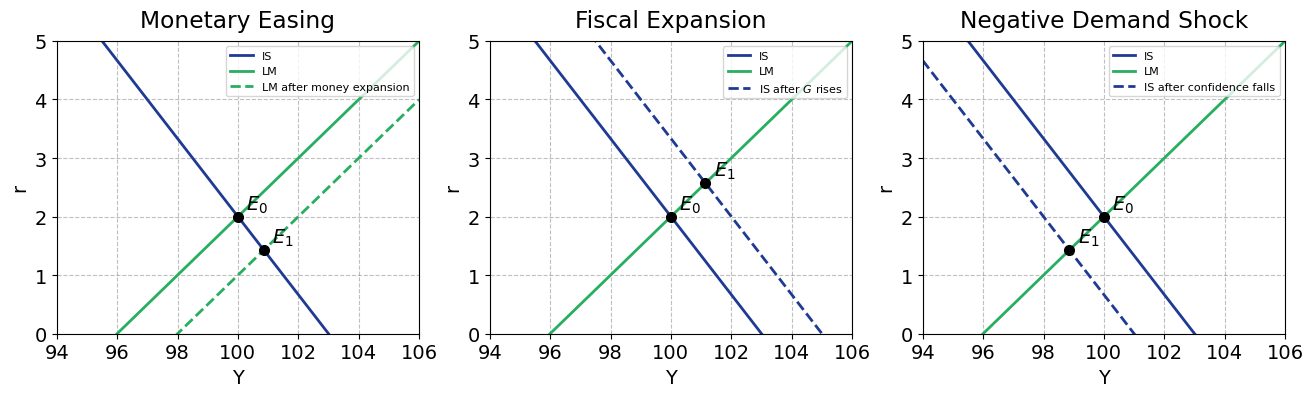

In [5]:
# === Plot IS-LM under three classroom scenarios ===
Y_grid = np.linspace(94, 106, 100)

scenarios = [
    {
        'title': 'Monetary Easing',
        'is_shock': 0.0,
        'lm_shock': 2.0,
        'shift': 'LM',
        'label': r'LM after money expansion',
    },
    {
        'title': 'Fiscal Expansion',
        'is_shock': 2.0,
        'lm_shock': 0.0,
        'shift': 'IS',
        'label': r'IS after $G$ rises',
    },
    {
        'title': 'Negative Demand Shock',
        'is_shock': -2.0,
        'lm_shock': 0.0,
        'shift': 'IS',
        'label': r'IS after confidence falls',
    },
]

fig = plt.figure(figsize=(13.2, 4.2))

for i, scenario in enumerate(scenarios):
    ax = fig.add_subplot(1, 3, i + 1)
    ax.plot(Y_grid, is_curve_level(Y_grid, par_islm),
            color='#1f3a93', lw=2, label='IS')
    ax.plot(Y_grid, lm_curve(Y_grid, par_islm),
            color='#27ae60', lw=2, label='LM')

    if scenario['shift'] == 'IS':
        ax.plot(Y_grid, is_curve_level(Y_grid, par_islm, shock=scenario['is_shock']),
                color='#1f3a93', lw=2, ls='--', label=scenario['label'])
    else:
        ax.plot(Y_grid, lm_curve(Y_grid, par_islm, shock=scenario['lm_shock']),
                color='#27ae60', lw=2, ls='--', label=scenario['label'])

    Y0, r0 = is_lm_equilibrium(par_islm)
    Y1, r1 = is_lm_equilibrium(
        par_islm,
        is_shock=scenario['is_shock'],
        lm_shock=scenario['lm_shock'],
    )
    ax.plot([Y0, Y1], [r0, r1], 'o', color='black', ms=7)
    ax.annotate(r'$E_0$', (Y0, r0), textcoords='offset points', xytext=(6, 5))
    ax.annotate(r'$E_1$', (Y1, r1), textcoords='offset points', xytext=(6, 5))

    ax.set_title(scenario['title'], pad=10)
    ax.set_xlabel('Y')
    ax.set_ylabel('r')
    ax.set_xlim(94, 106)
    ax.set_ylim(0, 5)
    ax.legend(fontsize=8, loc='upper right')

fig.tight_layout()

With an upward-sloping LM curve, monetary easing shifts LM right and lowers the interest rate. A fiscal expansion shifts IS right and raises both output and the interest rate, so crowding out appears inside the diagram.

### <a id='toc1_3_1_'></a>[Try it yourself](#toc0_)

Modify the IS-LM diagram and check your intuition.

1. In the fiscal expansion panel, set `g_lm = 0.0`. What happens to the size of the output effect?
2. Build a fourth scenario in which both $G$ and confidence rise by the same amount.
3. Add a panel where the central bank offsets the negative demand shock by shifting the policy line down.

In [6]:
# write your code here

## <a id='toc1_4_'></a>[The Taylor rule and the horizontal policy line](#toc0_)

Modern monetary-policy models replace the upward-sloping LM curve with a horizontal line at the real interest rate chosen by the central bank. Output is then read from the IS curve at that policy rate.

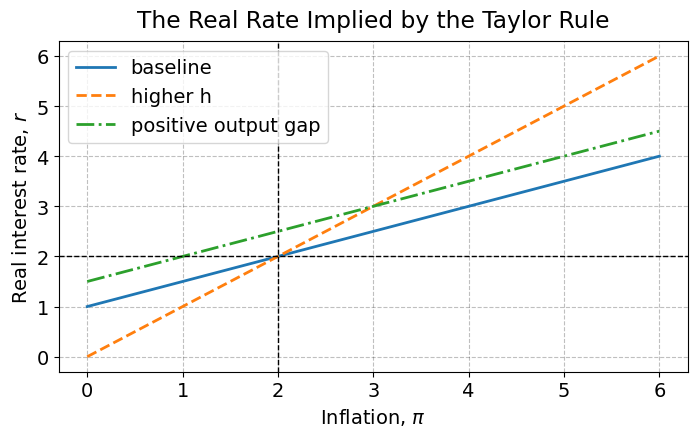

In [7]:
# === Baseline monetary-policy parameters ===
par_mp = {
    'r_bar': 2.0,    # neutral real rate
    'pi_star': 2.0,  # inflation target
    'h': 0.5,        # Taylor inflation response
    'b': 0.5,        # Taylor output-gap response
    'y_gap': 0.0,    # output gap
    'rho_hat': 0.0,  # spread between policy and relevant market rate
}

def real_rate_from_taylor(pi, p):
    '''Return the real rate implied by the Taylor rule.'''
    r_bar = p['r_bar']
    pi_star = p['pi_star']
    h = p['h']
    b = p['b']
    y_gap = p['y_gap']
    rho_hat = p['rho_hat']

    return r_bar + h * (pi - pi_star) + b * y_gap + rho_hat

pi_grid = np.linspace(0.0, 6.0, 301)

par_hawk = par_mp.copy()
par_hawk['h'] = 1.0

par_hot = par_mp.copy()
par_hot['y_gap'] = 1.0

fig = plt.figure(figsize=(7.2, 4.6))
ax = fig.add_subplot(1, 1, 1)

ax.plot(pi_grid, real_rate_from_taylor(pi_grid, par_mp),
        lw=2, label='baseline')
ax.plot(pi_grid, real_rate_from_taylor(pi_grid, par_hawk),
        lw=2, ls='--', label='higher h')
ax.plot(pi_grid, real_rate_from_taylor(pi_grid, par_hot),
        lw=2, ls='-.', label='positive output gap')

ax.axvline(par_mp['pi_star'], lw=1, ls='--', color='black')
ax.axhline(par_mp['r_bar'],   lw=1, ls='--', color='black')
ax.set_title('The Real Rate Implied by the Taylor Rule', pad=10)
ax.set_xlabel(r'Inflation, $\pi$')
ax.set_ylabel(r'Real interest rate, $r$')
ax.legend(loc='upper left')

fig.tight_layout()

A larger inflation response $h$ makes the real rate rise more sharply when inflation is above target. A positive output gap or spread shifts the whole schedule upward, which tightens financial conditions for households and firms.

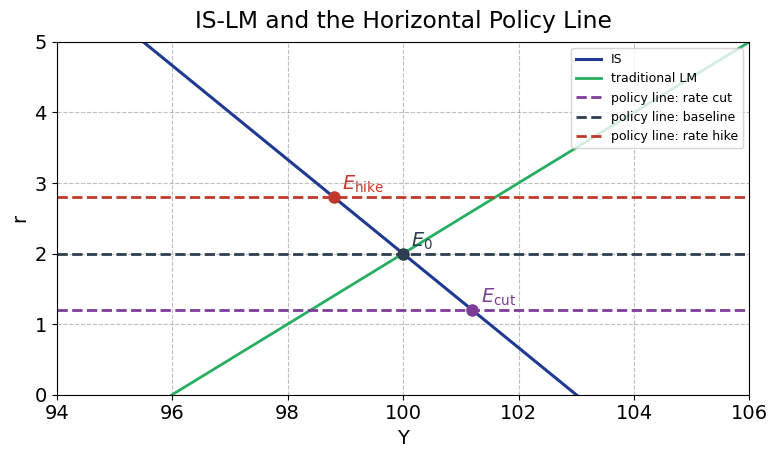

In [8]:
# === Traditional LM versus horizontal policy line ===
Y_grid = np.linspace(94, 106, 200)
r_policy_low = par_islm['r_bar'] - 0.8
r_policy_base = par_islm['r_bar']
r_policy_high = par_islm['r_bar'] + 0.8

def policy_line(Y, r_policy):
    '''Return a horizontal policy line.'''
    return np.full_like(Y, r_policy, dtype=float)

def policy_equilibrium(p, r_policy, is_shock=0.0):
    '''Return output where IS meets a horizontal policy line.'''
    Y_eq = p['Y_bar'] + is_shock - p['alpha2'] * (r_policy - p['r_bar'])
    return Y_eq, r_policy

fig = plt.figure(figsize=(8.0, 4.8))
ax = fig.add_subplot(1, 1, 1)

ax.plot(Y_grid, is_curve_level(Y_grid, par_islm),
        color='#1f3a93', lw=2.2, label='IS')
ax.plot(Y_grid, lm_curve(Y_grid, par_islm),
        color='#27ae60', lw=2.0, label='traditional LM')
ax.plot(Y_grid, policy_line(Y_grid, r_policy_low),
        color='#7d3c98', lw=2, ls='--', label='policy line: rate cut')
ax.plot(Y_grid, policy_line(Y_grid, r_policy_base),
        color='#2c3e50', lw=2, ls='--', label='policy line: baseline')
ax.plot(Y_grid, policy_line(Y_grid, r_policy_high),
        color='#c0392b', lw=2, ls='--', label='policy line: rate hike')

for r_policy, color, label in [
    (r_policy_low, '#7d3c98', r'$E_{\mathrm{cut}}$'),
    (r_policy_base, '#2c3e50', r'$E_0$'),
    (r_policy_high, '#c0392b', r'$E_{\mathrm{hike}}$'),
]:
    Y_eq, r_eq = policy_equilibrium(par_islm, r_policy)
    ax.plot(Y_eq, r_eq, 'o', color=color, ms=8)
    ax.annotate(label, (Y_eq, r_eq), textcoords='offset points', xytext=(6, 5), color=color)

ax.set_title('IS-LM and the Horizontal Policy Line', pad=10)
ax.set_xlabel('Y')
ax.set_ylabel('r')
ax.set_xlim(94, 106)
ax.set_ylim(0, 5)
ax.legend(fontsize=9, loc='upper right')

fig.tight_layout()

The traditional LM curve makes the interest rate endogenous to money-market equilibrium. The horizontal policy line instead fixes the real rate, so a rate cut moves the economy along IS to higher output.

### <a id='toc1_4_1_'></a>[Try it yourself](#toc0_)

Use the same plotting code, but now introduce a spread shock.

1. Set `rho_hat = 1.0`.
2. Replot the real-rate rule.
3. Explain why this matters for private demand even if the policy rule itself is unchanged.

In [9]:
# write your code here

## <a id='toc1_5_'></a>[From IS-LM to the AD curve](#toc0_)

Combining the IS curve with the policy rule gives the AD curve. Higher inflation raises the policy rate, the horizontal policy line moves up, and output falls along the IS curve.

Combining the IS curve with the Taylor rule gives the AD curve

$$
y-\bar y = z - a(\pi-\pi^*),
$$

where

$$
a = \frac{\alpha_2 h}{1+\alpha_2 b}, \qquad
z = \frac{\alpha_1(g-\bar g)-\alpha_3(\tau-\bar \tau)+v-\alpha_2\hat\rho}{1+\alpha_2 b}.
$$

The plot below shows inflation on the vertical axis and the output gap on the horizontal axis. This is the same $(y,\pi)$ diagram used in the slides.

### <a id='toc1_5_1_'></a>[Bridge figure: tracing AD from IS and the policy line](#toc0_)

The left panel shows the IS curve with two horizontal monetary-policy lines. The right panel reads off the corresponding $(Y,\pi)$ pairs and traces the AD curve.

AD slope a = alpha2*h/(1+alpha2*b) = 0.750


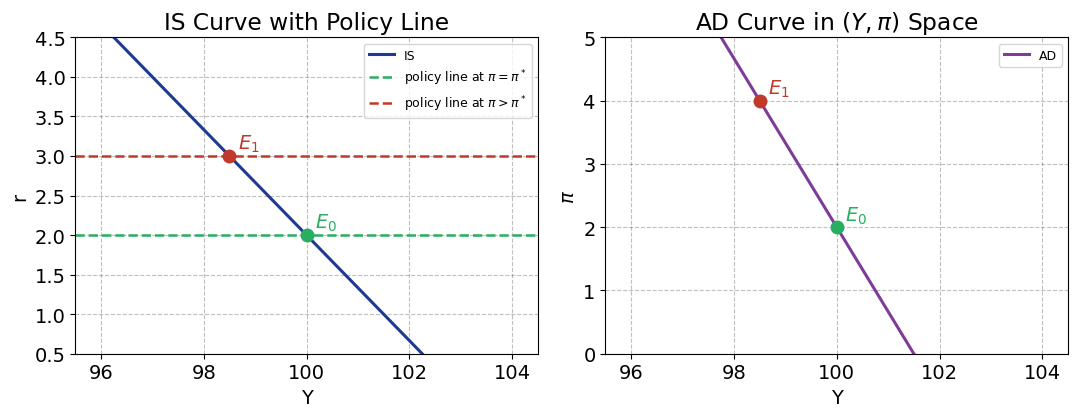

In [10]:
# === Bridge figure: from IS and the horizontal policy line to AD ===
par_bridge = {
    'y_bar':  100.0,
    'r_bar':  2.0,
    'alpha2': 1.5,
    'h':      0.5,
    'b':      0.0,
    'pi_star': 2.0,
}

def bridge_points(pi, p):
    '''Given inflation pi, return (Y, r) along IS plus the policy rule.'''
    r = p['r_bar'] + p['h'] * (pi - p['pi_star'])
    Y = p['y_bar'] - p['alpha2'] * (r - p['r_bar'])
    return Y, r

pi_low, pi_high = par_bridge['pi_star'], par_bridge['pi_star'] + 2.0
Y_low,  r_low   = bridge_points(pi_low,  par_bridge)
Y_high, r_high  = bridge_points(pi_high, par_bridge)

a_bridge = par_bridge['alpha2'] * par_bridge['h'] / (1.0 + par_bridge['alpha2'] * par_bridge['b'])

fig = plt.figure(figsize=(11.0, 4.4))

ax = fig.add_subplot(1, 2, 1)
r_grid = np.linspace(0.5, 4.5, 100)
Y_IS = par_bridge['y_bar'] - par_bridge['alpha2'] * (r_grid - par_bridge['r_bar'])
ax.plot(Y_IS, r_grid, color='#1f3a93', lw=2.2, label='IS')
ax.hlines(r_low,  95.5, 104.5, color='#27ae60', lw=1.8, ls='--', label=r'policy line at $\pi=\pi^*$')
ax.hlines(r_high, 95.5, 104.5, color='#c0392b', lw=1.8, ls='--', label=r'policy line at $\pi>\pi^*$')
ax.plot(Y_low,  r_low,  'o', color='#27ae60', ms=9)
ax.plot(Y_high, r_high, 'o', color='#c0392b', ms=9)
ax.annotate(r'$E_0$', (Y_low, r_low), textcoords='offset points', xytext=(6, 5), color='#27ae60')
ax.annotate(r'$E_1$', (Y_high, r_high), textcoords='offset points', xytext=(6, 5), color='#c0392b')
ax.set_xlim(95.5, 104.5)
ax.set_ylim(0.5, 4.5)
ax.set_xlabel('Y')
ax.set_ylabel('r')
ax.set_title('IS Curve with Policy Line')
ax.legend(fontsize=9)

ax = fig.add_subplot(1, 2, 2)
pi_grid = np.linspace(0, 5, 100)
Y_AD = par_bridge['y_bar'] - a_bridge * (pi_grid - par_bridge['pi_star'])
ax.plot(Y_AD, pi_grid, color='#7d3c98', lw=2.2, label='AD')
ax.plot(Y_low,  pi_low,  'o', color='#27ae60', ms=9)
ax.plot(Y_high, pi_high, 'o', color='#c0392b', ms=9)
ax.annotate(r'$E_0$', (Y_low, pi_low), textcoords='offset points', xytext=(6, 5), color='#27ae60')
ax.annotate(r'$E_1$', (Y_high, pi_high), textcoords='offset points', xytext=(6, 5), color='#c0392b')
ax.set_xlim(95.5, 104.5)
ax.set_ylim(0, 5)
ax.set_xlabel('Y')
ax.set_ylabel(r'$\pi$')
ax.set_title(r'AD Curve in $(Y, \pi)$ Space')
ax.legend(fontsize=9)

fig.tight_layout()

print(f'AD slope a = alpha2*h/(1+alpha2*b) = {a_bridge:.3f}')

The AD curve is generated by policy behavior, not drawn independently. Higher inflation moves the policy line up, and the IS curve then implies lower output.

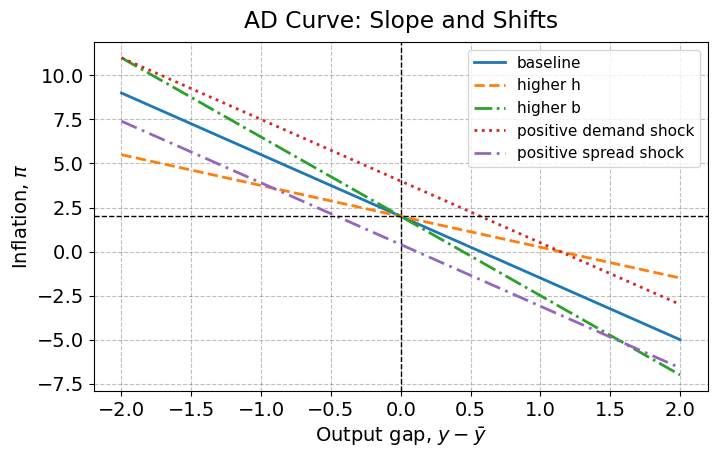

In [11]:
# === Baseline AD parameters ===
par_ad = {
    'alpha1': 1.0,
    'alpha2': 0.8,
    'alpha3': 0.6,
    'h': 0.5,
    'b': 0.5,
    'pi_star': 2.0,
    'g_gap': 0.0,
    'tau_gap': 0.0,
    'v': 0.0,
    'rho_hat': 0.0,
}

def ad_objects(p):
    '''Return the slope parameter a and the shock term z.'''
    alpha1 = p['alpha1']
    alpha2 = p['alpha2']
    alpha3 = p['alpha3']
    h = p['h']
    b = p['b']
    g_gap = p['g_gap']
    tau_gap = p['tau_gap']
    v = p['v']
    rho_hat = p['rho_hat']

    a = alpha2 * h / (1.0 + alpha2 * b)
    z = (alpha1 * g_gap - alpha3 * tau_gap + v - alpha2 * rho_hat) / (1.0 + alpha2 * b)

    return a, z

def ad_inflation(y_gap, p):
    '''Return inflation implied by the AD curve.'''
    a, z = ad_objects(p)
    return p['pi_star'] + (z - y_gap) / a

y_gap_grid = np.linspace(-2.0, 2.0, 301)

par_h = par_ad.copy()
par_h['h'] = 1.0

par_b = par_ad.copy()
par_b['b'] = 1.0

par_v_pos = par_ad.copy()
par_v_pos['v'] = 0.8

par_risk = par_ad.copy()
par_risk['rho_hat'] = 0.8

fig = plt.figure(figsize=(7.4, 4.8))
ax = fig.add_subplot(1, 1, 1)

ax.plot(y_gap_grid, ad_inflation(y_gap_grid, par_ad),
        lw=2, label='baseline')
ax.plot(y_gap_grid, ad_inflation(y_gap_grid, par_h),
        lw=2, ls='--', label='higher h')
ax.plot(y_gap_grid, ad_inflation(y_gap_grid, par_b),
        lw=2, ls='-.', label='higher b')
ax.plot(y_gap_grid, ad_inflation(y_gap_grid, par_v_pos),
        lw=2, ls=':', label='positive demand shock')
ax.plot(y_gap_grid, ad_inflation(y_gap_grid, par_risk),
        lw=2, dashes=(6, 2, 1, 2), label='positive spread shock')

ax.axvline(0.0, lw=1, ls='--', color='black')
ax.axhline(par_ad['pi_star'], lw=1, ls='--', color='black')
ax.set_title('AD Curve: Slope and Shifts', pad=10)
ax.set_xlabel(r'Output gap, $y - \bar y$')
ax.set_ylabel(r'Inflation, $\pi$')
ax.legend(loc='upper right', fontsize=11)

fig.tight_layout()

A stronger inflation response $h$ makes AD flatter because inflation triggers a larger real-rate increase. Demand shocks shift AD through $z$, while policy parameters change how strongly output responds to inflation.

### <a id='toc1_5_2_'></a>[Try it yourself](#toc0_)

Check that you can separate movements along AD from shifts of AD.

1. Increase `g_gap` to `0.5` and replot the AD curve.
2. Increase `rho_hat` to `0.5` and replot the AD curve.
3. Lower `pi_star` to `1.5`. Explain why changing the target is not the same as a standard demand shock.

In [12]:
# write your code here

## <a id='toc1_6_'></a>[Data lab: policy rates and central bank balance sheets](#toc0_)

Policy-rate data show the short-rate instrument in the model. Balance-sheet data proxy for unconventional policy that works through market-rate wedges, term premia, and spreads.

### <a id='toc1_6_1_'></a>[FRED data access](#toc0_)

In [13]:
fred_api_key = "9fb7818ec505ebe0f36e58efc607471c"
use_live_download = True

Plot two objects that correspond directly to the lecture mechanisms.

1. The Fed and ECB policy rates since 2016, which correspond to the short-rate instrument in the Taylor-rule block.
2. The Fed and Eurosystem balance sheets, which correspond to unconventional policy tools that try to affect market-rate wedges, term premia, and spreads.

In [14]:
def download_fred_csv(series_id):
    '''Download one FRED series and return DATE plus the series column.'''
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': fred_api_key,
        'file_type': 'json',
        'observation_start': '2016-01-01',
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    observations = response.json()['observations']

    df = pd.DataFrame(observations)
    df = df.rename(columns={'date': 'DATE', 'value': series_id})
    df['DATE'] = pd.to_datetime(df['DATE'])
    df[series_id] = pd.to_numeric(df[series_id], errors='coerce')

    df = df[['DATE', series_id]]
    df = df.dropna()

    return df

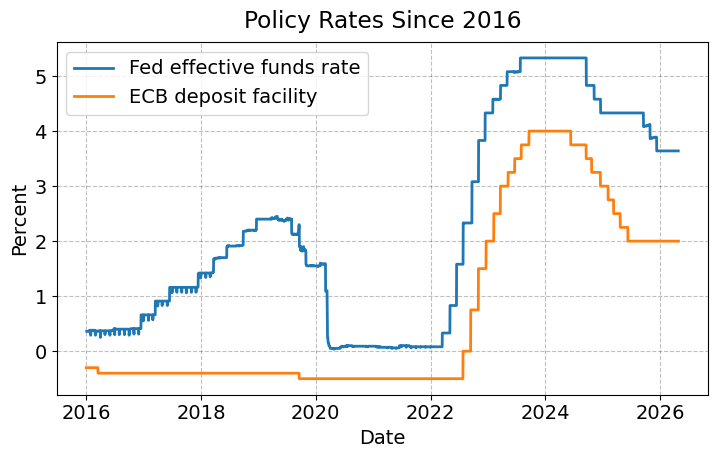

In [15]:
effr = download_fred_csv('EFFR')
ecb = download_fred_csv('ECBDFR')

fig = plt.figure(figsize=(7.4, 4.8))
ax = fig.add_subplot(1, 1, 1)

ax.plot(effr['DATE'], effr['EFFR'], lw=2, label='Fed effective funds rate')
ax.plot(ecb['DATE'], ecb['ECBDFR'], lw=2, label='ECB deposit facility')

ax.set_title('Policy Rates Since 2016', pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Percent')
ax.legend(loc='upper left')

fig.tight_layout()

The post-2022 rise in policy rates is the real-world version of the Taylor-rule channel: higher inflation leads to tighter monetary policy. Denmark is linked to the ECB cycle through the fixed exchange-rate regime, so euro-area policy is especially relevant.

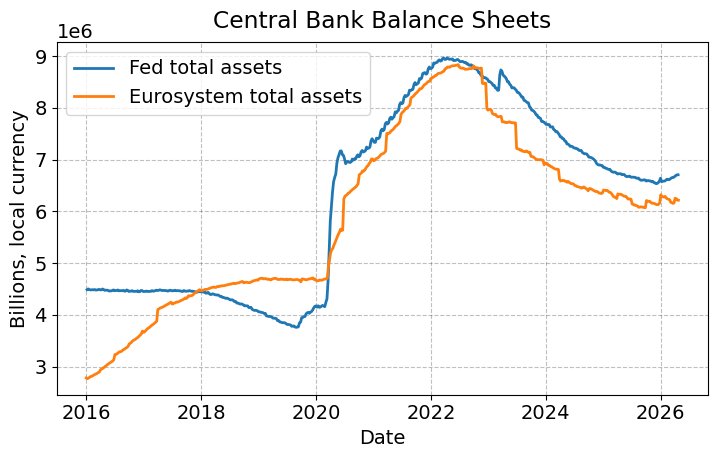

In [16]:
walcl = download_fred_csv('WALCL')
ecb_assets = download_fred_csv('ECBASSETSW')

fig = plt.figure(figsize=(7.4, 4.8))
ax = fig.add_subplot(1, 1, 1)

ax.plot(walcl['DATE'], walcl['WALCL'], lw=2, label='Fed total assets')
ax.plot(ecb_assets['DATE'], ecb_assets['ECBASSETSW'], lw=2, label='Eurosystem total assets')

ax.set_title('Central Bank Balance Sheets', pad=10)
ax.set_xlabel('Date')
ax.set_ylabel('Billions, local currency')
ax.legend(loc='upper left')

fig.tight_layout()

Balance-sheet expansion is associated with quantitative easing, which aims to influence term premia and spreads when the short-rate channel is weak. In the Chapter 17 model, this works through the wedge between the policy rate and market rates.

## <a id='toc1_7_'></a>[Summary](#toc0_)

| Equation | Meaning |
|---|---|
| $Y = \frac{1}{1-c(1-t)}(C_0-cT_0+I_0-br+G)$ | **Exact Linear IS Benchmark** |
| $y - \bar y = \alpha_1(g-\bar g) - \alpha_2(r-\bar r) - \alpha_3(\tau-\bar \tau) + v$ | **Reduced-Form IS Curve** |
| $r = \bar r + g_{LM}(Y-\bar Y)$ | **Traditional LM Curve** |
| $r = r^{policy}$ | **Horizontal Monetary-Policy Line** |
| $i^p = \bar r + \pi^e + h(\pi-\pi^*) + b(y-\bar y)$ | **Taylor Rule** |
| $r \approx \bar r + h(\pi-\pi^*) + b(y-\bar y) + \hat\rho$ | **Real-Rate Rule Used in the AD Derivation** |
| $y - \bar y = z - a(\pi-\pi^*)$ | **AD Curve** |

**Socrative room:** MACROECONOMICSB